In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict, Counter
from networkx.algorithms import bipartite
import matplotlib.patches as mpatches
import networkx as nx
import random


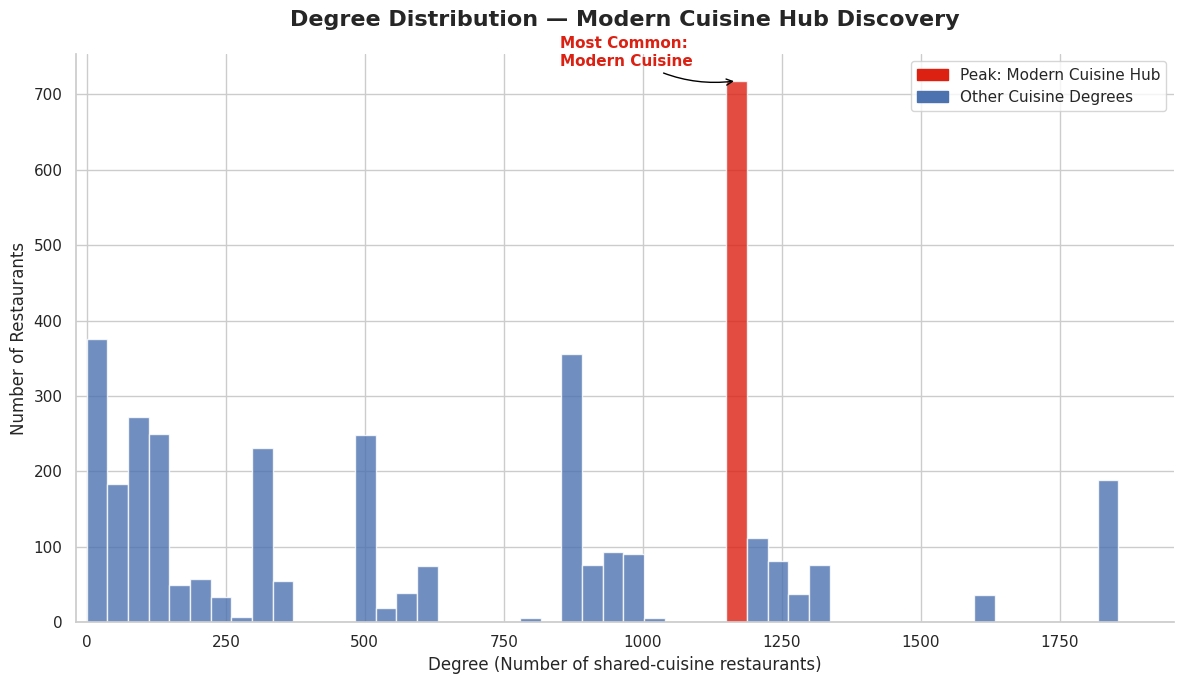

In [3]:

# plot settings
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

# load and filter data
df = pd.read_csv("Michelin_cleaned up.csv")
df = df[df["Award"].isin(["1 Star", "2 Stars", "3 Stars"])].copy()

# Parse cuisine strings into lists and map each cuisine to its set of restaurants
df["Cuisine_List"] = df["Cuisine"].fillna("").apply(lambda x: [c.strip() for c in x.split(",") if c.strip()])
cuisine_map = defaultdict(set)
for idx, row in df.iterrows():
    for cuisine in row["Cuisine_List"]:
        cuisine_map[cuisine].add(row["Name"])

# Calculate Degree
# Degree = number of unique restaurants sharing atleast one cuisine category
df["Degree"] = df.apply(lambda r: len(set().union(*(cuisine_map[c] for c in r["Cuisine_List"]))) - 1, axis=1)

#compute the histogram and identify the peak bin
min_deg, max_deg = df["Degree"].min(), df["Degree"].max()
counts, bins = np.histogram(df["Degree"], bins=50, range=(min_deg, max_deg))
# Find the bin with the highest restaurant count
max_bin_idx = np.argmax(counts)
peak_val = int(bins[max_bin_idx])

#Identify the Dominant cuisine that is driving the peak
peak_restaurants = df[(df["Degree"] >= bins[max_bin_idx]) & (df["Degree"] <= bins[max_bin_idx+1])]
all_cuisines_in_peak = [c for sublist in peak_restaurants["Cuisine_List"] for c in sublist]
top_cuisine_name = Counter(all_cuisines_in_peak).most_common(1)[0][0]

# Plot the degree distribution
color_main = "#4C72B0"
color_peak = "#DC2012"

# Highlight the peak bin
colors = [color_main] * len(counts)
colors[max_bin_idx] = color_peak

plt.bar(bins[:-1], counts, width=np.diff(bins), align="edge", color=colors, edgecolor="white", alpha=0.8)

# Legend
red_patch = mpatches.Patch(color=color_peak, label=f'Peak: {top_cuisine_name} Hub')
blue_patch = mpatches.Patch(color=color_main, label='Other Cuisine Degrees')
plt.legend(handles=[red_patch, blue_patch], loc='upper right', frameon=True, fontsize=11)

#  Annotatate the peak bin
plt.annotate(
    f'Most Common:\n{top_cuisine_name}',
    xy=(bins[max_bin_idx] + (np.diff(bins)[0]/2), counts[max_bin_idx]),
    xytext=(bins[max_bin_idx] -300, counts[max_bin_idx] + 20),
    arrowprops=dict(arrowstyle="->", color="black", connectionstyle="arc3,rad=.2"),
    fontsize=11, fontweight='bold', color=color_peak
)

# aix labels and formatting
plt.xlim(min_deg - 20, max_deg + 100)
plt.title(f"Degree Distribution — {top_cuisine_name} Hub Discovery", fontsize=16, pad=20, fontweight='bold')
plt.xlabel("Degree (Number of shared-cuisine restaurants)", fontsize=12)
plt.ylabel("Number of Restaurants", fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()





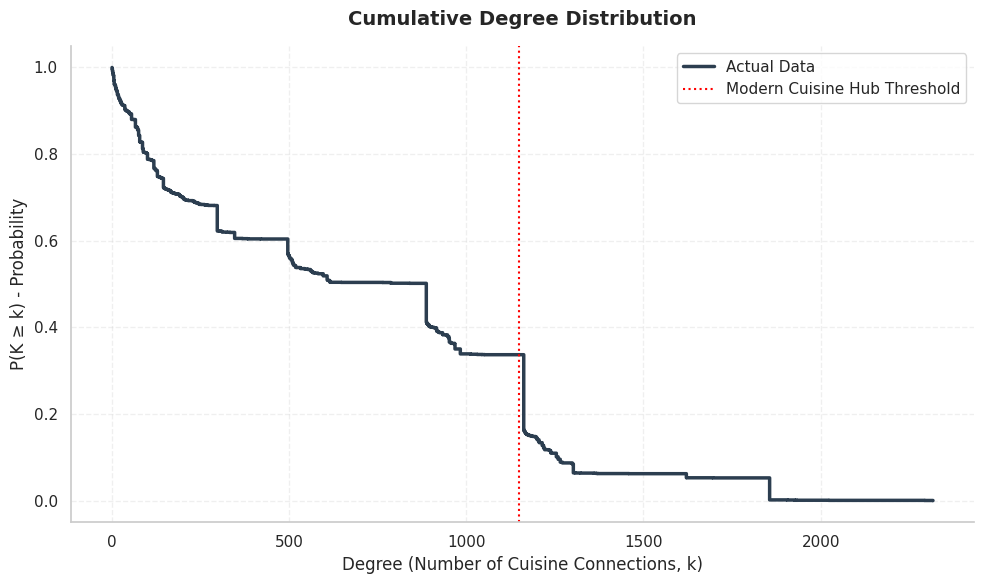

In [4]:

# Filter data for 1, 2, and 3 Stars restaurants
star_tiers = ["1 Star", "2 Stars", "3 Stars"]
df_stars = df[df["Award"].isin(star_tiers)].copy()

# Parse cuisne strings into lists
df_stars["Cuisine_List"] = df_stars["Cuisine"].fillna("").apply(
    lambda x: [c.strip() for c in x.split(",") if c.strip()]
)

# Build a Bipartite Graph ( restaurant <-> cuisine)
# Each restaurant is a node. Edges connect restaurants to their cuisine
B = nx.Graph()
for _, row in df_stars.iterrows():
    res_name = row['Name']
    B.add_node(res_name, bipartite=0)
    for cuisine in row['Cuisine_List']:
        B.add_node(cuisine, bipartite=1)
        B.add_edge(res_name, cuisine)

# Project to restaurant nodes
# Two restaurants are connected if they share at least one cuisine category
res_nodes = [n for n, d in B.nodes(data=True) if d['bipartite'] == 0]
G = bipartite.projected_graph(B, res_nodes)

#  Calculate cumulative degree distribution
# P(K ≥ k) = fraction of nodes with degree greater than or equal to k
degrees = [d for n, d in G.degree()]
degrees_sorted = np.sort(degrees)
# P(K >= k) = fraction of nodes with degree >= current degree
p_cdf = 1. * np.arange(len(degrees), 0, -1) / len(degrees)

# plot the Visualization
plt.figure(figsize=(10, 6))
# Mark the degree threshold where the Modern Cuisine hub dominates
plt.step(degrees_sorted, p_cdf, where='post', color='#2c3e50', linewidth=2.5, label='Actual Data')

#Formatting
plt.title('Cumulative Degree Distribution', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Degree (Number of Cuisine Connections, k)', fontsize=12)
plt.ylabel('P(K ≥ k) - Probability', fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.axvline(x=1150, color='red', linestyle=':', label='Modern Cuisine Hub Threshold')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
# Basic degree statisctis to characterize the spread and connectivity of the network

degrees = [d for n, d in G.degree()]
print(f"Max Degree: {np.max(degrees)}")
print(f"Average Degree: {np.mean(degrees):.2f}")
print(f"Standard Deviation: {np.std(degrees):.2f}")

Max Degree: 2317
Average Degree: 696.22
Standard Deviation: 539.65


In [10]:
# Generate Null Model (Degree Preserving)
# Preserves the degree sequence of the real network while randomizing connections
degree_sequence = [d for n, d in G.degree()]
G_null_multi = nx.configuration_model(degree_sequence, seed=42)

# Convert to simple graph by removing multi-edges and self-loops
G_null = nx.Graph(G_null_multi)
G_null.remove_edges_from(nx.selfloop_edges(G_null))

#  Clustering Coefficient by sampling a subset of nodes
def get_sampled_clustering(graph, samples=10000):
    nodes = list(graph.nodes())
    sample_nodes = random.sample(nodes, min(len(nodes), samples))
    return nx.average_clustering(graph, nodes=sample_nodes)

print("Calculating sampled clustering coefficients...")
real_clust = get_sampled_clustering(G)
null_clust = get_sampled_clustering(G_null)
print(f"Real Network: {real_clust:.4f}")
print(f"Null Model:   {null_clust:.4f}")


Calculating sampled clustering coefficients...
Real Network: 0.9021
Null Model:   0.3454


In [16]:
# Degree Standard Deviation
real_degrees = [d for n, d in G.degree()]
null_degrees  = [d for n, d in G_null.degree()]
real_std = np.std(real_degrees)
null_std  = np.std(null_degrees)

# Average Path Length (Giant Component Only)
# Path length is undefined for disconnected nodes, so we restrict to the giant component
# Sampling pairs is used to avoid the O(n²) cost of computing all shortest paths
def get_sampled_path_length(graph, samples=10000):
    giant_nodes = max(nx.connected_components(graph), key=len)
    G_giant = graph.subgraph(giant_nodes)
    nodes = list(G_giant.nodes())
    lengths = [
        nx.shortest_path_length(G_giant, *random.sample(nodes, 2))
        for _ in range(samples)
    ]
    return np.mean(lengths)

print(f"Real Network Std Dev: {real_std:.2f}")
print(f"Null Model Std Dev:   {null_std:.2f}")

print("\nCalculating average path lengths...")
real_path_len = get_sampled_path_length(G)
null_path_len = get_sampled_path_length(G_null)
print(f"Real Network: {real_path_len:.2f}")
print(f"Null Model:   {null_path_len:.2f}")


Real Network Std Dev: 539.65
Null Model Std Dev:   397.83

Calculating average path lengths...
Real Network: 1.93
Null Model:   1.90


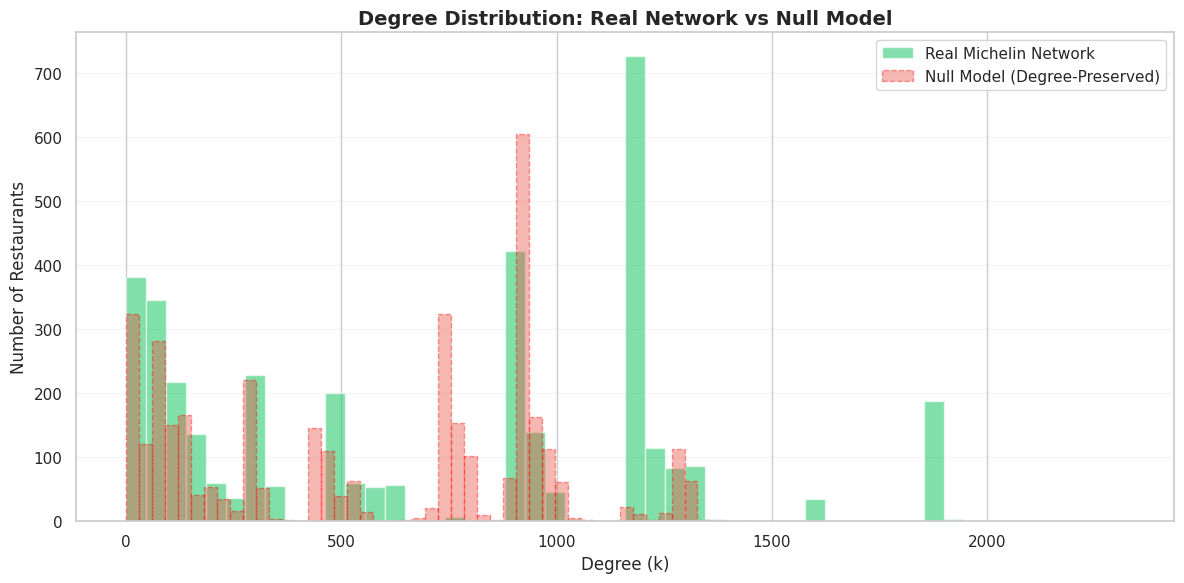

In [17]:
# Degree Distribution: Real vs Null Model
plt.figure(figsize=(12, 6))

plt.hist(real_degrees, bins=50, alpha=0.6, label='Real Michelin Network', color='#2ecc71')
plt.hist(null_degrees, bins=50, alpha=0.4, label='Null Model (Degree-Preserved)',
         color='#e74c3c', edgecolor='red', linestyle='dashed')

plt.title('Degree Distribution: Real Network vs Null Model', fontsize=14, fontweight='bold')
plt.xlabel('Degree (k)', fontsize=12)
plt.ylabel('Number of Restaurants', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

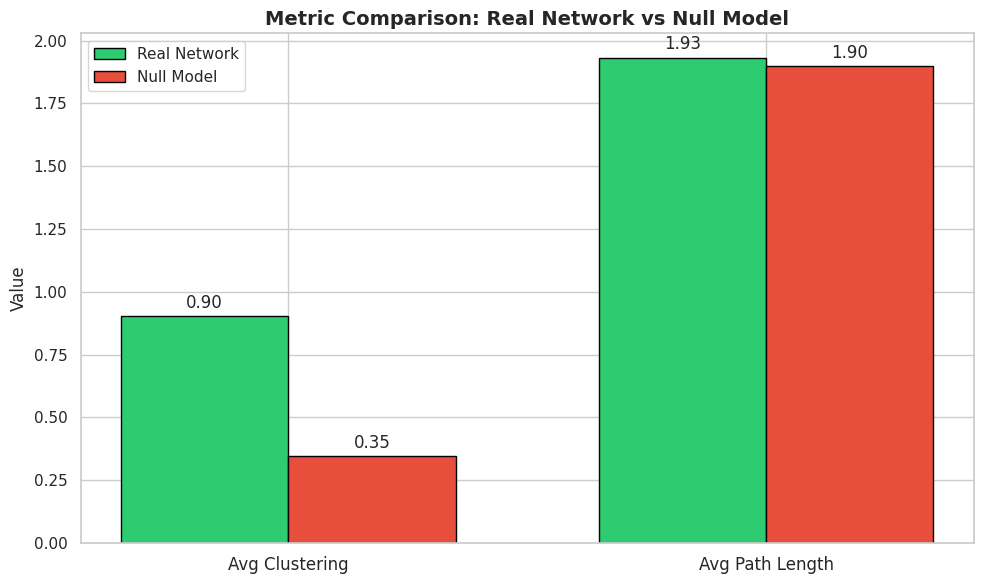

In [18]:
# Metric Comparison: Real Network vs Null Model
# Values computed in previous cells
metrics = ['Avg Clustering', 'Avg Path Length']
real_values = [real_clust, real_path_len]
null_values = [null_clust, null_path_len]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

# Grouped bars for side-by-side comparison
rects1 = ax.bar(x - width/2, real_values, width, label='Real Network', color='#2ecc71', edgecolor='black')
rects2 = ax.bar(x + width/2, null_values, width, label='Null Model', color='#e74e3c', edgecolor='black')

# Add value labels on top of each bar
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

ax.set_ylabel('Value', fontsize=12)
ax.set_title('Metric Comparison: Real Network vs Null Model', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

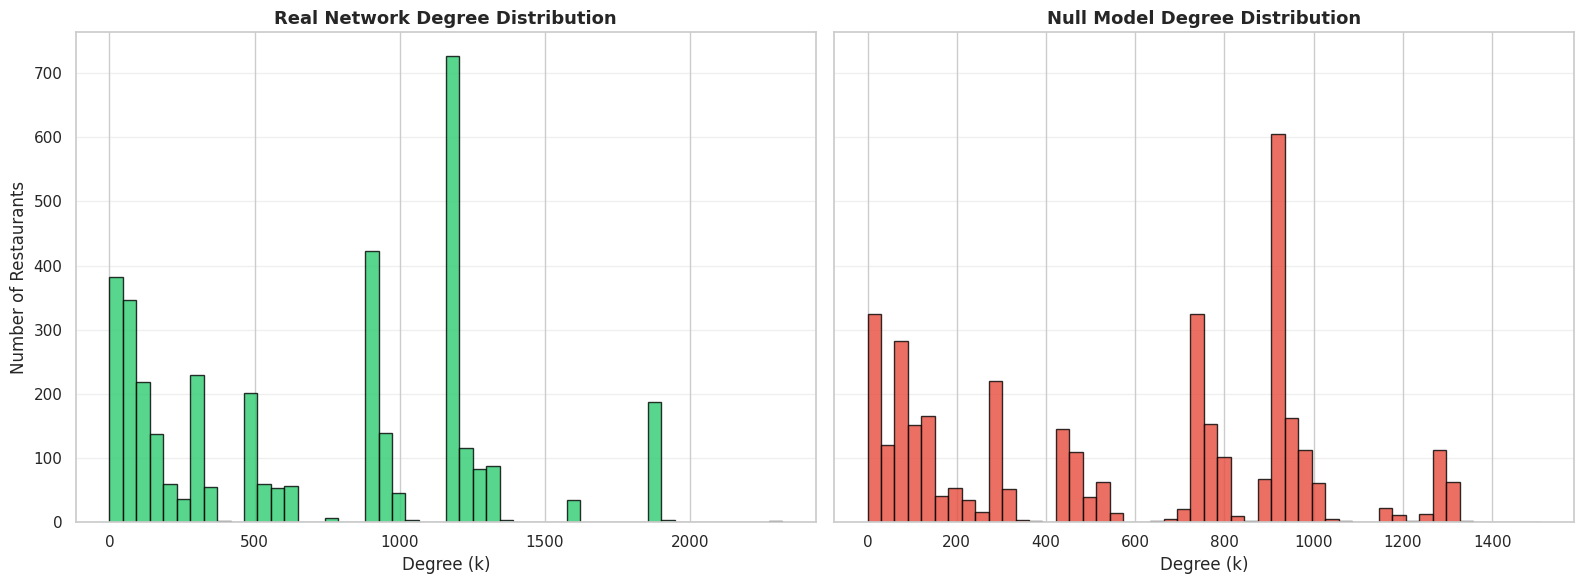

In [19]:
# Degree Distribution: Side-by-Side Comparison

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Real network
ax1.hist(real_degrees, bins=50, color='#2ecc71', edgecolor='black', alpha=0.8)
ax1.set_title('Real Network Degree Distribution', fontweight='bold', fontsize=13)
ax1.set_xlabel('Degree (k)', fontsize=12)
ax1.set_ylabel('Number of Restaurants', fontsize=12)
ax1.grid(axis='y', alpha=0.3)

# Null model
ax2.hist(null_degrees, bins=50, color='#e74c3c', edgecolor='black', alpha=0.8)
ax2.set_title('Null Model Degree Distribution', fontweight='bold', fontsize=13)
ax2.set_xlabel('Degree (k)', fontsize=12)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
# Null Model Iteration Analysis
# Runs multiple null model iterations with different seeds to get a
# distribution of clustering and path length values for comparison

n_iterations = 10
degree_sequence = [d for n, d in G.degree()]
null_clustering_list = []
null_path_list = []

print(f"Starting {n_iterations} iterations for degree-preserving null model...")

for i in range(n_iterations):
    # Build a new null model with a unique seed per iteration
    G_null_multi = nx.configuration_model(degree_sequence, seed=i)
    G_null_iter = nx.Graph(G_null_multi)
    G_null_iter.remove_edges_from(nx.selfloop_edges(G_null_iter))

    # Clustering coefficient
    avg_c = nx.average_clustering(G_null_iter)
    null_clustering_list.append(avg_c)

    # Path length on giant component using sampled pairs
    GC_null = G_null_iter.subgraph(max(nx.connected_components(G_null_iter), key=len))
    pairs = list(np.random.choice(list(GC_null.nodes()), size=(10000, 2)))
    lengths = []
    for u, v in pairs:
        try:
            lengths.append(nx.shortest_path_length(GC_null, u, v))
        except nx.NetworkXNoPath:
            continue
    null_path_list.append(np.mean(lengths))

    print(f"  Iteration {i+1}/{n_iterations} complete.")

# Results
print("\n--- Degree-Preserving Null Model Results ---")
print(f"Clustering Mean: {np.mean(null_clustering_list):.4f}")
print(f"Clustering Std:  {np.std(null_clustering_list):.4f}")
print(f"Path Length Mean: {np.mean(null_path_list):.4f}")
print(f"Path Length Std:  {np.std(null_path_list):.4f}")

Starting 10 iterations for degree-preserving null model...
  Iteration 1/10 complete.
  Iteration 2/10 complete.
  Iteration 3/10 complete.
  Iteration 4/10 complete.
  Iteration 5/10 complete.
  Iteration 6/10 complete.
  Iteration 7/10 complete.
  Iteration 8/10 complete.
  Iteration 9/10 complete.
  Iteration 10/10 complete.

--- Degree-Preserving Null Model Results ---
Clustering Mean: 0.3456
Clustering Std:  0.0007
Path Length Mean: 1.8989
Path Length Std:  0.0057
